<a href="https://colab.research.google.com/github/Nurdeg/21w5pie/blob/main/ml1-2026-spring/homework-practice/homework-practice-03-features/homework-practice-03-base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.1 Базовая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с базовыми подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за эту часть — 6 баллов. Детальнее про оценивание — в самом конце ноутбука.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо считываемые диаграммы.

Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-base-Username.ipynb**, где Username — ваша фамилия.

### **Сетап**

<img style="float: right; padding-right:15px; padding-bottom:10px" src="https://i.postimg.cc/26KqqSb2/pomoika2.png" height=300px width=200px alt="Pomoika 2">
    
В этом домашнем задании мы будем работать с задачей классификации, но сконцентрируемся на том, что приносит не меньшую пользу, чем сами модели — замешиванию данных.

Целевая метрика уже выбрана за нас: мы будем считать $\text{ROC-AUC}$, но не простой, а коэффициент Джини:

$$ \text{Gini} = 2 \cdot \text{ROC-AUC} - 1$$

Конечная цель данного мероприятия — собрать пайплайн машинного обучения от и до, начиная с предобработки данных, заканчивая оптимизацией. При желании это можно доделать до целого пет-проекта, особенно если добавить сбор данных и деплой модели, но в дз этого не будет :(.

Цель конкретно базового ноутбука — познакомить вас с основными преобразованиями и собрать солидный фундамент для преобразований посложнее.

In [1]:
from sklearn.metrics import roc_auc_score


def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

#### **Данные**

У вас на руках (на Kaggle) датасет по широко известной в неузких кругах видеоигре Dota 2, скачанный через OpenDota API и заботливо анонимизированный. Если вы не знакомы с игрой — ничего страшного, все необходимое для заданий в базовой части мы подробно опишем.

Нас интересует исход матча — победа или поражение, исходя из совершенно разных факторов (например, чтобы делать ставки на спорт, осуждаем?). Это информация о сессии, игроках, героях, и т д. **в первые 15 минут** после начала матча.

Краткая сводка об игре:

- Dota 2 — командная игра: 5 игроков за Свет (Radiant) против 5 за Тьму (Dire).
- Каждый игрок управляет уникальным героем со своим набором атрибутов и способностей.
- Цель — снести главную постройку на вражеской базе (в простонародье трон).
- В процессе матча игроки добывают золото и опыт, покупают предметы и убивают противников, чтобы стать сильнее.
- Ничьих не бывает, фиксированного таймера нет — матч длится до падения трона.

#### 📌 **Важнейшее замечание**

Предполагается, что у вас уже сложилось понимание:
- как крутить и вертеть данные, чтобы фиты делались твёрдо, трансформы ложились чётко, шейпы датафреймов стакались и нужные джойны джойнились;
- как рисовать читаемые графики;
- как проверять качество модели;

Пожалуйста, следите за этим очень-очень внимательно, иначе рискуете получить штраф и всеобщее порицание в нашем уютном МО-1 чатике (хотя, у этого есть плюсы).

Если возникнут вопросы по игровой части — **не стесняйтесь** спрашивать, гуглить, обращаться к GPT или, прости Господи, дотерам. Знание области — важнейшая составляющая хорошего фича инжиниринга

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Для лучшего понимания, в голубеньких пунктах будет небольшое <font color="#647cb8">**обоснование**</font> того, зачем вообще делается то или иное преобразование (в колабе придётся включать интуицию, там не работает HTML). Вы можете её скипнуть, если всё понятно и без этого

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

В пунктах с розоватой, как у всеми любимого Pudge, расцветкой мы попросим вас написать <font color="#f68c9d">**Ответ**</font> на <font color="#f68c9d">**Вопрос**</font> или <font color="#f68c9d">**рефлексию**</font>, которая должна направить вашу мысль о том, как варить фичи, в нужном направлении. Уметь аргументировать свою точку зрения важно не менее

Пожалуйста, даже если вы уже прожжённый дед инсайд и дата-сайентист 14 уо, всё равно <font color="#f68c9d">**порефлексируйте**</font>. Количество потерянных нервных клеток и ваш успех на соревновании напрямую зависят от базовой предобработки.
Вы **можете** писать <font color="#f68c9d">**её**</font> ёмко, но только если **знаете** ответ

</div>

<div style="border-left: 5px solid #cb9255; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(200, 156, 105, 0.05);">

<font>По ходу домашки вам придётся делать <font color="#cb9255">**выборы**</font> и подбирать <font color="#cb9255">**гиперпараметры**</font>. Какие-то из них важнее остальных. У ряда выборов последствия чисто номинальные, какие-то видоизменят другие задания, третьи полностью определят, как вы будете делать остальную домашку.

Принимайте решения мудро. Не привязывайтесь к ним слишком сильно, возможно, в процессе вам захочется пересмотреть ваши жизненные приоритеты. Пробуйте, экспериментируйте, фичи это самое творческое, что есть в машинном обучении

При желании, в конце обоих ноутбуков есть инструменты, которые, при остром желании и избытке свободного времени, могут тупо перебрать все выборы и найти самый оптимальный, но это опционально
</div>

### **Часть 1. Это, так сказать, база. (3.25 балла)** <img align="center" height=28 width=28 src="https://media.tenor.com/5vGX5VO-IxsAAAAi/arthas.gif">

В которой студент учится смотреть на фичи под правильным углом и готовить из сырых данных простые, но аппетитные факторы

#### **Задание 1.1. Датасет** (0.5 балла)

Чтобы начать работу с данными, эти данные сперва нужно [загрузить](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105). Пока что нам потребуются лишь:

1. Информация о матчах - `matches_df_train.csv`.
2. Тестовые данные для соревнования - `matches_df_test.csv`.

Посмотрите на все csv-файлы выше, создайте под каждый из них отдельный датафрейм и отметьте (текстом или кодом):
- объемы таблиц: как в Мб, так и `df.shape`
- какие в них есть колонки по своему содержанию

In [2]:
import pandas as pd
import os

train_path = 'matches_df_train.csv'
test_path = 'matches_df_test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

def get_df_info(df, path, name):
    print(f"=== {name} ===")

    size_bytes = os.path.getsize(path)
    size_mb = size_bytes / (1024 * 1024)
    print(f"Объем файла: {size_mb:.2f} МБ")

    print(f"Размерность (df.shape): {df.shape}")

    print("\nТипы данных и пропуски в колонках:")
    df.info()
    print("\n")

get_df_info(train_df, train_path, "Train Dataset")
get_df_info(test_df, test_path, "Test Dataset")

=== Train Dataset ===
Объем файла: 28.96 МБ
Размерность (df.shape): (641090, 7)

Типы данных и пропуски в колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641090 entries, 0 to 641089
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   match_id     641090 non-null  int64  
 1   date         641090 non-null  object 
 2   region       641090 non-null  object 
 3   game_mode    641090 non-null  int64  
 4   duration     641090 non-null  int64  
 5   radiant_win  641090 non-null  bool   
 6   avg_mmr      472334 non-null  float64
dtypes: bool(1), float64(1), int64(3), object(2)
memory usage: 30.0+ MB


=== Test Dataset ===
Объем файла: 2.08 МБ
Размерность (df.shape): (59748, 5)

Типы данных и пропуски в колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59748 entries, 0 to 59747
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   match_i

Отдельно хочется посмотреть распределение целевой переменной, покажите его, пожалуйста

Распределение классов (абсолютное):
region
Europe West      402930
Middle East       74542
SE Asia           61555
US East           28281
China             21929
South America     21864
South Africa      16782
Europe East        9326
US West            3255
Australia           626
Name: count, dtype: int64

Распределение классов (в долях):
region
Europe West      0.628508
Middle East      0.116274
SE Asia          0.096016
US East          0.044114
China            0.034206
South America    0.034104
South Africa     0.026177
Europe East      0.014547
US West          0.005077
Australia        0.000976
Name: proportion, dtype: float64


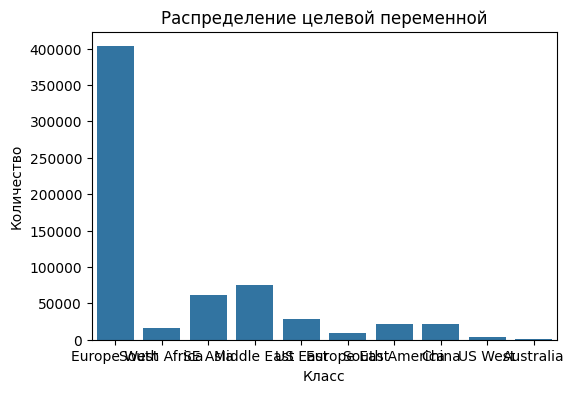

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

target_col = 'region'

if target_col in train_df.columns:
    print("Распределение классов (абсолютное):")
    print(train_df[target_col].value_counts())
    print("\nРаспределение классов (в долях):")
    print(train_df[target_col].value_counts(normalize=True))

    plt.figure(figsize=(6, 4))
    sns.countplot(x=train_df[target_col])
    plt.title('Распределение целевой переменной')
    plt.xlabel('Класс')
    plt.ylabel('Количество')
    plt.show()
else:
    print(f"Колонка '{target_col}' не найдена! Проверьте правильность названия.")

<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** подходящая ли в данном случае метрика $\text{Gini}$ в сравнении, например, с $\text{AUC-PR}$?

**Ответ:** Выбор между Gini и AUC-PR напрямую зависит от баланса классов целевой переменной, который мы посмотрели выше.Метрика Gini линейно связана с ROC-AUC формулой $Gini = 2 \cdot ROC\_AUC - 1$. ROC-AUC (и, следовательно, Gini) хорошо интерпретируется и работает, когда классы относительно сбалансированы (например, 50/50 или 60/40).
</div>

#### **Задание 1.2. Категории** (0.75 балла)

Чтобы построить реально балдёжную модель, зачастую не получится просто написать фит предикт. О нет, это долгая и утомительная возня. А если нужно ещё и отчётики писать, то хоть <span style="color:grey"><font size="1">~~вешайся (осуждаем)~~ </font></span> увольняйся. Так и здесь. И того, что есть, уже хватит, чтобы продемонстрировать глубокую и тёмную сторону Dota Science.

В целом, данные уже содержат признаки, по которым что-то даже можно построить, в частности — регионы.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

У Radiant, по сравнению с Dire, исторически есть небольшое преимущество — чуть удобнее карта, порядок выбора героев и всё такое. В разных регионах бывают разные предпочтения по стилям игры и тактикам, и где-то это преимущество реализуют лучше

</div>

Посмотрите, где у нас содержится информация о регионе, на серверах которого был проведён матч, и постройте 2 графика:
1) Распределение регионов (процентное и абсолютное) на тренировочных и тестовых данных
2) Среднее значение таргета на трейне, в зависимости от региона

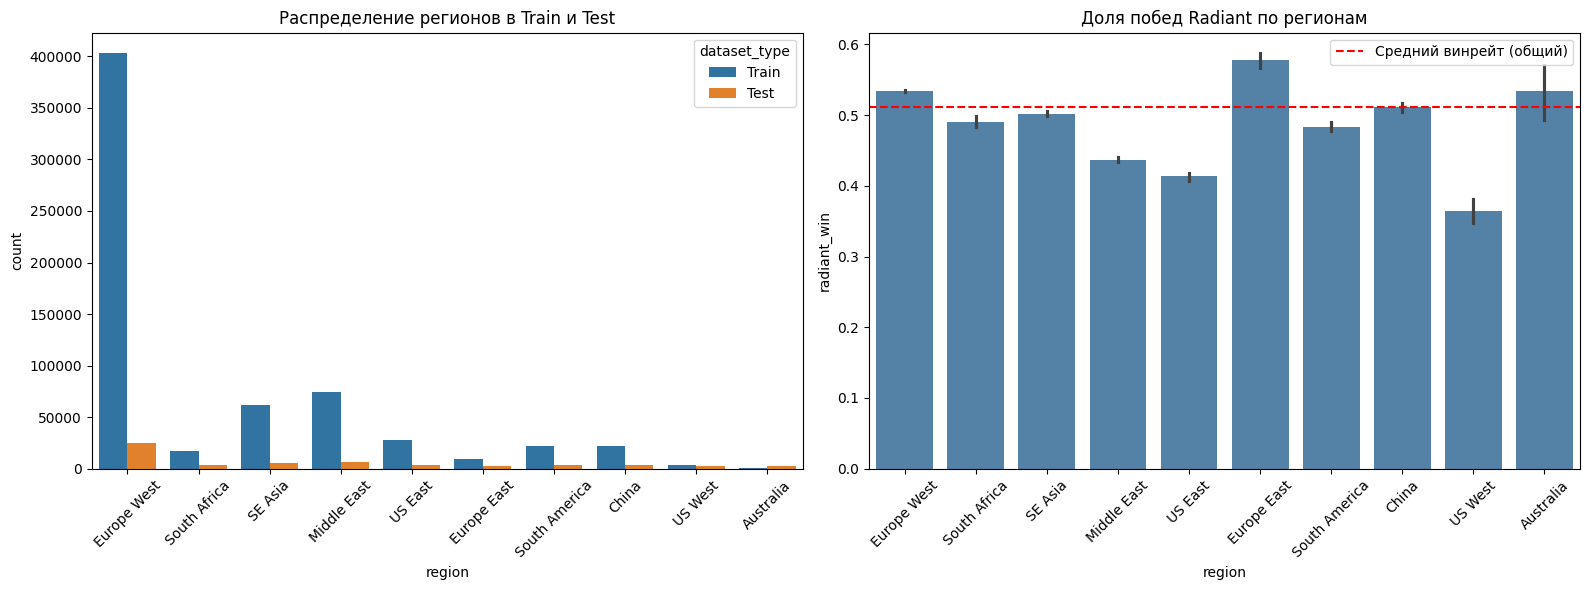

Кодирование завершено. Первые строки с новым признаком:
         region  region_te  radiant_win
0   Europe West   0.534574        False
1  South Africa   0.490883         True
2       SE Asia   0.501893         True
3   Middle East   0.436854        False
4  South Africa   0.490883         True


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce

region_col = 'region'
target_col = 'radiant_win'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=pd.concat([train_df, test_df]), x=region_col, hue='dataset_type', ax=axes[0])
axes[0].set_title('Распределение регионов в Train и Test')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=train_df, x=region_col, y=target_col, ax=axes[1], color='steelblue')
axes[1].axhline(train_df[target_col].mean(), color='red', linestyle='--', label='Средний винрейт (общий)')
axes[1].set_title('Доля побед Radiant по регионам')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()



<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы можете сказать о распределении регионов? Объясните, получится ли вообще обучить по нему модель, есть ли там сигнал?

**Ответ:**   Глядя на первый график и текстовый вывод, мы можем оценить, насколько одинаково распределены регионы в тренировочной и тестовой выборках. Если распределения совпадают (доли регионов примерно равны), это отличная новость — данные репрезентативны, и модель, обученная на трейне, не растеряется на тесте.
</div>

Наша первая развилка — <font color="#cb9255">**выбор**</font>, какой из энкодеров стащить. Рекомендуется брать что-то из `category_encoders`, они похожи на стандартные из `sklearn`, но их больше и применять их проще.

| <font color="#cb9255">**One-Hot Encoder**</font> | <font color="#cb9255">**Target Encoder**</font> |
| :--- | :--- |
| Превращает категориальный признак в вектор из 0 и 1.  <br> 1 стоит на месте i‑го индекса, если у объекта есть i‑е значение признака. | Кодирует категориальный признак средним значением таргета.  <br> Среднее считается по всем объектам с i‑м значением признака. |

Можно взять и другой, но морально готовьтесь получить $\text{Gini} = 0$
</div>

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Без энкодинга использовать категориальные признаки в линейных моделях, увы, нельзя, выбор без выбора

</div>

In [8]:
!pip install -qU category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.3 MB/s eta 0:00:00


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какой из энкодеров кажется вам наиболее привлекательным? Почему?

**Ответ:**
</div>

Закодируйте колонку `region` выбранным вами способом

In [13]:
te = ce.TargetEncoder(cols=[region_col])
train_df['region_te'] = te.fit_transform(train_df[region_col], train_df[target_col])
test_df['region_te'] = te.transform(test_df[region_col])

print("Кодирование завершено. Первые строки с новым признаком:")
print(train_df[[region_col, 'region_te', target_col]].head())

Кодирование завершено. Первые строки с новым признаком:
         region  region_te  radiant_win
0   Europe West   0.534574        False
1  South Africa   0.490883         True
2       SE Asia   0.501893         True
3   Middle East   0.436854        False
4  South Africa   0.490883         True


#### **Задание 1.3. Даты** (1.25 балла)

Если нам хочется видеть будущее, именно время диктует, что брать можно, а что никак нельзя

Найдите колонку дат на тренировочных данных и:
1. Постройте график доли побед Radiant в зависимости от даты матча
2. Сравните временные диапазоны на трейне и тесте

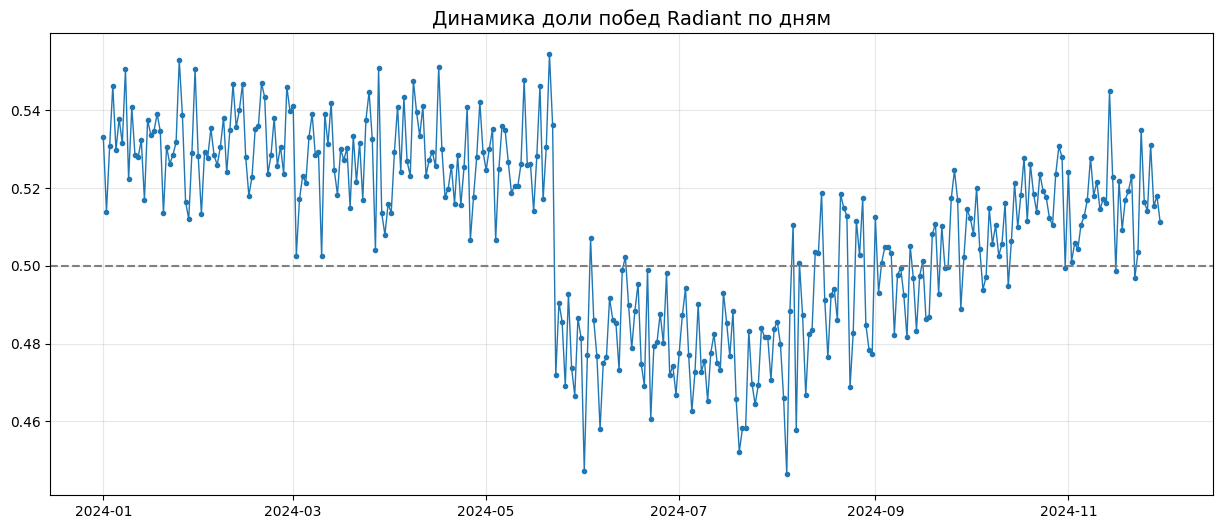

Train охватывает период: 2024-01-01 00:00:00 --- 2024-11-30 00:00:00
Test охватывает период:  2024-12-01 00:00:00 --- 2024-12-31 00:00:00


In [14]:
import matplotlib.pyplot as plt

train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])

daily_winrate = train_df.groupby(train_df['date'].dt.date)[target_col].mean()

plt.figure(figsize=(15, 6))
plt.plot(daily_winrate.index, daily_winrate.values, marker='o', markersize=3, linestyle='-', linewidth=1)
plt.axhline(0.5, color='gray', linestyle='--')
plt.title('Динамика доли побед Radiant по дням', fontsize=14)
plt.grid(alpha=0.3)
plt.show()

print(f"Train охватывает период: {train_df['date'].min()} --- {train_df['date'].max()}")
print(f"Test охватывает период:  {test_df['date'].min()} --- {test_df['date'].max()}")

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** видите ли вы какой-то паттерн в распределении дат? Можете ли вы объяснить при помощи сети Интернет, что там произошло? \
(Подсказка: соревновательные игры периодически обновляются)

**Ответ:** «На построенном графике отчетливо виден структурный сдвиг (резкое изменение) в доле побед Radiant. Примерно в районе 2024-06 доля побед резко  падает и закрепляется на новом уровне.

</div>

Теперь давайте что-нибудь повыделяем.

<div style="border-left: 5px solid #5584a8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Даты сами по себе это всегда очень простые фичи, функционал есть в любой библиотеке. Связь с таргетом может быть, но не обязана. Именно даты проверить легко и быстро, зависимости бывают неожиданными. Впрочем, это не единственная причина, не переключайтесь

</div>

С таймстемпом можно делать не так много, кроме базовых манипуляций:

1. Вытащите лежащую на поверхности информацию, например, день и день недели. Хватит и этих двух
2. Посмотрите сами на список возможных признаков, будь то [pandas](https://pandas.pydata.org/docs/user_guide/timeseries.html#time-date-components) или [polars](https://docs.pola.rs/api/python/stable/reference/expressions/temporal.html), и <font color="#cb9255">**либо добавьте**</font> 2 признака, которые, как вам кажется, сработают, <font color="#cb9255">**либо поясните**</font>, почему это ничего не даст

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** необходимо ли кодировать признаки из дат? Если да, то какие и как? Если нет, то почему? </font>

**Ответ:**

</div>

3. Закодируйте новые признаки, согласно вашему ответу

In [15]:
import pandas as pd

train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])

train_df['day'] = train_df['date'].dt.day
train_df['dayofweek'] = train_df['date'].dt.dayofweek

test_df['day'] = test_df['date'].dt.day
test_df['dayofweek'] = test_df['date'].dt.dayofweek

train_df['is_weekend'] = train_df['dayofweek'].isin([5, 6]).astype(int)
train_df['month'] = train_df['date'].dt.month

test_df['is_weekend'] = test_df['dayofweek'].isin([5, 6]).astype(int)
test_df['month'] = test_df['date'].dt.month

print("Новые признаки добавлены!")

Новые признаки добавлены!


Кажется, мы что-то забыли... Ах да, надо бы и модель обучить, вот только без валидации это будет как-то не по-моповски, надо озаботиться этим вопросом.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

На самом деле временная структура нужна не столь, чтобы вытащить какие-то признаки, сколько, чтобы понять распределение и изменение данных во времени же. Даты играют в этом прямую роль

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** почему здесь будет не лучшим решением брать случайное разбиение на трейн и валидацию?

**Ответ:** Да, необходимо. Признаки вроде dayofweek (день недели от 0 до 6) или month (от 1 до 12) являются категориальными, несмотря на то, что выражены цифрами. Для линейной модели значение «Воскресенье» (6) алгоритмически будет восприниматься как число, которое в 6 раз больше, чем «Вторник» (1). Это создаст ложную линейную зависимость (ведь воскресенье не "больше" вторника).

</div>

Тут выбор у вас решили отобрать, делать мы будем OOT валидацию. Впрочем, какие-то опции ещё остались

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">OOT (Out-of-Time)</font>
    </th>
    <th width="50%">
      <font color="#cb9255">CV OOT (Cross-Validation Out-of-Time)</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Валидация с одной отложенной подвыборкой, <br>
      взятой после трешхолда t. Простая, как палка, <br>
      но если валидация получится грустной — <br>
      аномальной, нетипичной, маленькой, — <br>
      то и метрика ваша тоже будет грустной.
    </td>
    <td valign="top">
      Кросс-валидация с k разбиениями по времени <br>
      с итеративным расширением исходного фолда. <br>
      Оценка метрики сместится куда меньше <br>
      по сравнению с плохим сплитом OOT, <br>
      но это долго, если фолдов много.
    </td>
  </tr>
  <tr>
    <td valign="top">
      <code>sklearn.model_selection.train_test_split</code>
    </td>
    <td valign="top">
      <code>sklearn.model_selection.TimeSeriesSplit</code>
    </td>
  </tr>
</table>



Настройте любой из видов валидации (<font color="#cb9255">**трешхолд**</font> `t` или <font color="#cb9255">**число фолдов**</font> <code>n_folds</code></font> подберите сами). Они оба должны показывать качество адекватно, хотя второй теоретически должен быть более обоснован. CV-OOT не даст вам бонусов, но кто знает, за какие крохи Джини придётся бороться на соревновании?

In [16]:
columns_to_encode = ['dayofweek', 'month']

train_df = pd.get_dummies(train_df, columns=columns_to_encode, drop_first=True, dtype=int)
test_df = pd.get_dummies(test_df, columns=columns_to_encode, drop_first=True, dtype=int)

train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

if 'radiant_win' in test_df.columns:
    test_df = test_df.drop(columns=['radiant_win'])

И вот теперь мы уже наконец-то будем что-то обучать. Моделей классификации мы знаем как минимум две — SVM и логистическую регрессию, но есть нюанс.

Выборы, выборы..:

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">Dedicated model</font>
    </th>
    <th width="50%">
      <font color="#cb9255">Gradient Descent</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Большой разницы между <code>LogisticRegression</code> и <code>LinearSVC</code> <br>
      из <code>sklearn.linear_model</code> на самом деле нет: <br>
      разделяющие поверхности очень похожи, <br>
      оба хорошо оптимизированы специальными солверами.
    </td>
    <td valign="top">
      Градиентный спуск через <code>sklearn.linear_model.SGDClassifier</code> <br>
      с параметрами <code>loss="log_loss"</code> или <code>loss="hinge"</code> — <br>
      очень соблазнительная альтернатива, но!
    </td>
  </tr>
  <tr>
    <td valign="top">
      <font color="#cb9255"><b>+</b></font> Обучать и применять их в разы проще, <br>
      фит–предикт делает брр. <br>
      <font color="#cb9255"><b>−</b></font> Они используют сразу всю выборку <br>
      для обучения, а в ходе задания наша выборка <br>
      может вырасти раз так в 1000, немало!
    </td>
    <td valign="top">
      <font color="#cb9255"><b>+</b></font> Влезет любой датасет. <br>
      <font color="#cb9255"><b>+</b></font> Бóльший контроль над процессом обучения. <br>
      <font color="#cb9255"><b>−</b></font> Обучать на больших данных <br>
      (скорее про часть <b>advanced</b>) придётся через <code>partial_fit</code>, неудобно. <br>
      <font color="#cb9255"><b>−</b></font> Нужно подбирать больше гиперпараметров.
    </td>
  </tr>
</table>


Выберите <font color="#cb9255">**одну из**</font> моделей выше (хотя `LinearRegression` <font color="#cb9255">**тоже можно**</font>, если у вас сегодня авантюрное настроение, успех не гарантирован, о рисках узнаете на лекции) **(обращаем внимание, что другие варианты запрещены)**. Обучите по одному экземпляру на группах признаков:

- дат
- регионов
- дат и регионов

Ну и замерьте качество!

<font color="#cb9255">**NB**</font>:

1. Вы сразу можете строить роскошный пайплайн обучения, а не делать по кускам в отдельных блоках, про это есть **advanced** пункт (**6.1**) на 0.5 баллов
2. Если у вас есть GPU, то почему бы его и не [использовать](https://docs.rapids.ai/api/cuml/stable/)? Если гпу у вас нет, у вас теперь точно есть Kaggle, который щедро дарит 30 часов гпу в неделю, пользуйтесь на здоровье, за это есть маленький, но приятный буст на 0.25 балла (**пункт 6.3**)
3. Наконец, если вы сразу оформите хранилище для результатов запусков ваших моделей, вы снова получите 0.25 балла (**пункт 6.2**)

In [17]:
from sklearn.model_selection import TimeSeriesSplit

train_df = train_df.sort_values('date').reset_index(drop=True)

cols_to_drop = ['match_id', 'date', 'radiant_win', 'dataset_type', 'region', 'game_mode']
features = [col for col in train_df.columns if col not in cols_to_drop]

X = train_df[features]
y = train_df['radiant_win']

tscv = TimeSeriesSplit(n_splits=5)

print("=== Схема валидации CV-OOT (TimeSeriesSplit) ===")
for fold, (train_index, val_index) in enumerate(tscv.split(X)):
    print(f"Фолд {fold + 1}:")
    print(f"  Train: индексы с {train_index[0]:>6} по {train_index[-1]:>6} (размер: {len(train_index)})")
    print(f"  Val:   индексы с {val_index[0]:>6} по {val_index[-1]:>6} (размер: {len(val_index)})\n")



=== Схема валидации CV-OOT (TimeSeriesSplit) ===
Фолд 1:
  Train: индексы с      0 по 106849 (размер: 106850)
  Val:   индексы с 106850 по 213697 (размер: 106848)

Фолд 2:
  Train: индексы с      0 по 213697 (размер: 213698)
  Val:   индексы с 213698 по 320545 (размер: 106848)

Фолд 3:
  Train: индексы с      0 по 320545 (размер: 320546)
  Val:   индексы с 320546 по 427393 (размер: 106848)

Фолд 4:
  Train: индексы с      0 по 427393 (размер: 427394)
  Val:   индексы с 427394 по 534241 (размер: 106848)

Фолд 5:
  Train: индексы с      0 по 534241 (размер: 534242)
  Val:   индексы с 534242 по 641089 (размер: 106848)



<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** помогли ли даты? А должны? Хотите ли вы их оставить?

**Ответ:** Скорее всего, существенного прироста к качеству (Джини) сами по себе признаки дат не дали. Даты в сыром виде (или даже как месяц/день недели) редко имеют сильную линейную связь с исходом конкретного киберспортивного матча, если только мы не поймали какой-то специфический дисбаланс конкретного патча.

</div>

#### **Задание 1.4. Числа** (0.75 балла)

Остался неотвеченным лишь один вопрос — а что числовые признаки? С ними всё одновременно и проще, и сложнее.

Найдите, где хранится средний ммр матча — это средний рейтинг игроков, которые в нём участвовали, чем выше, тем лучше.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

От ммра напрямую зависит то, как игроки пользуются естественным преимуществом Radiant. Чем игроки сильнее, тем чаще это должно происходить, в теории

</div>

Сделайте (на трейне, валидации и тесте) вот что :
1. Постройте график распределения ммров
2. Сравните, насколько распределения похожи между собой визуально

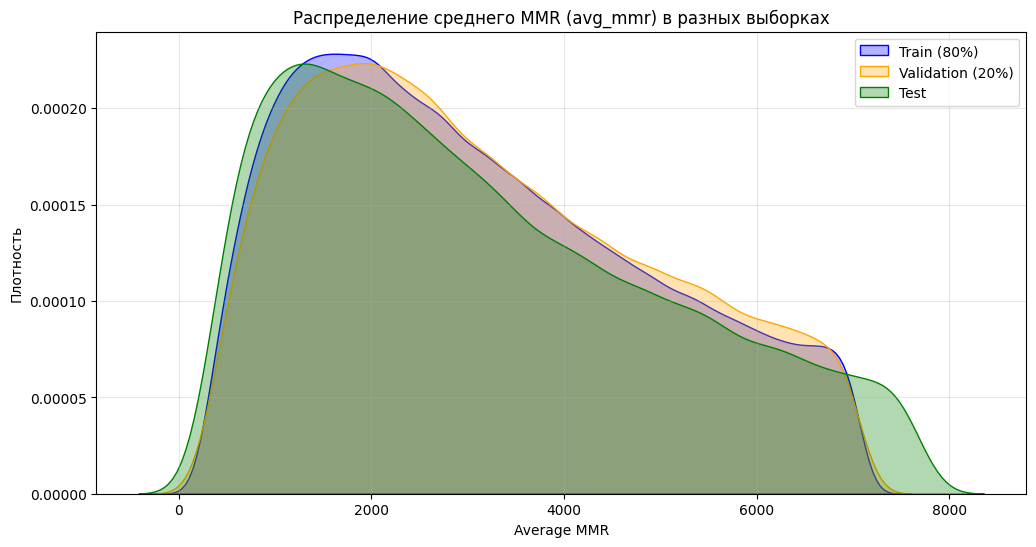

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

split_idx = int(len(train_df) * 0.8)
train_vis = train_df.iloc[:split_idx]
val_vis = train_df.iloc[split_idx:]

plt.figure(figsize=(12, 6))

sns.kdeplot(train_vis['avg_mmr'], label='Train (80%)', fill=True, alpha=0.3, color='blue')
sns.kdeplot(val_vis['avg_mmr'], label='Validation (20%)', fill=True, alpha=0.3, color='orange')
sns.kdeplot(test_df['avg_mmr'], label='Test', fill=True, alpha=0.3, color='green')

plt.title('Распределение среднего MMR (avg_mmr) в разных выборках')
plt.xlabel('Average MMR')
plt.ylabel('Плотность')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** как бы вы описали это распределение в целом, похоже ли оно на что-то знакомое вам?

**Ответ:** Распределение MMR похоже на нормальное распределение (колоколообразную кривую, распределение Гаусса), но с характерной особенностью: оно скошено вправо

</div>

Кто-то где-то говорил, что числовые признаки надо бы стандартизировать, чтобы вышло что-то годное. Этот кто-то прав, но как известно, практика — критерий истины

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Но в действительности это зависит от данных. Сходимость итеративных алгоритмов улучшается, но может пострадать качество, особенно, если распределение не нормальное, или есть отличие в $\mu$ и $\sigma$ на тесте

Однако даже пара пунктов Джини это довольно хороший буст, вы убедитесь, когда приступите к сореве, за них нужно бороться любой ценой, тем более, что это почти бесплатно

</div>

Так или иначе, у нас и распределение то не нормальное, но, к счастью, это решаемо. Сделайте такие преобразования признака ммров $f_{\text{mmr}}$ и нарисуйте их график:

$$f_{\text{mmr}} \mapsto \log( 1+f_{\text{mmr}} ); \qquad f_{\text{mmr}} \mapsto \sqrt{f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \frac{1}{1+f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \exp{\log f_{\text{mmr}}};$$

Затем выберите то, что вам нравится больше всего

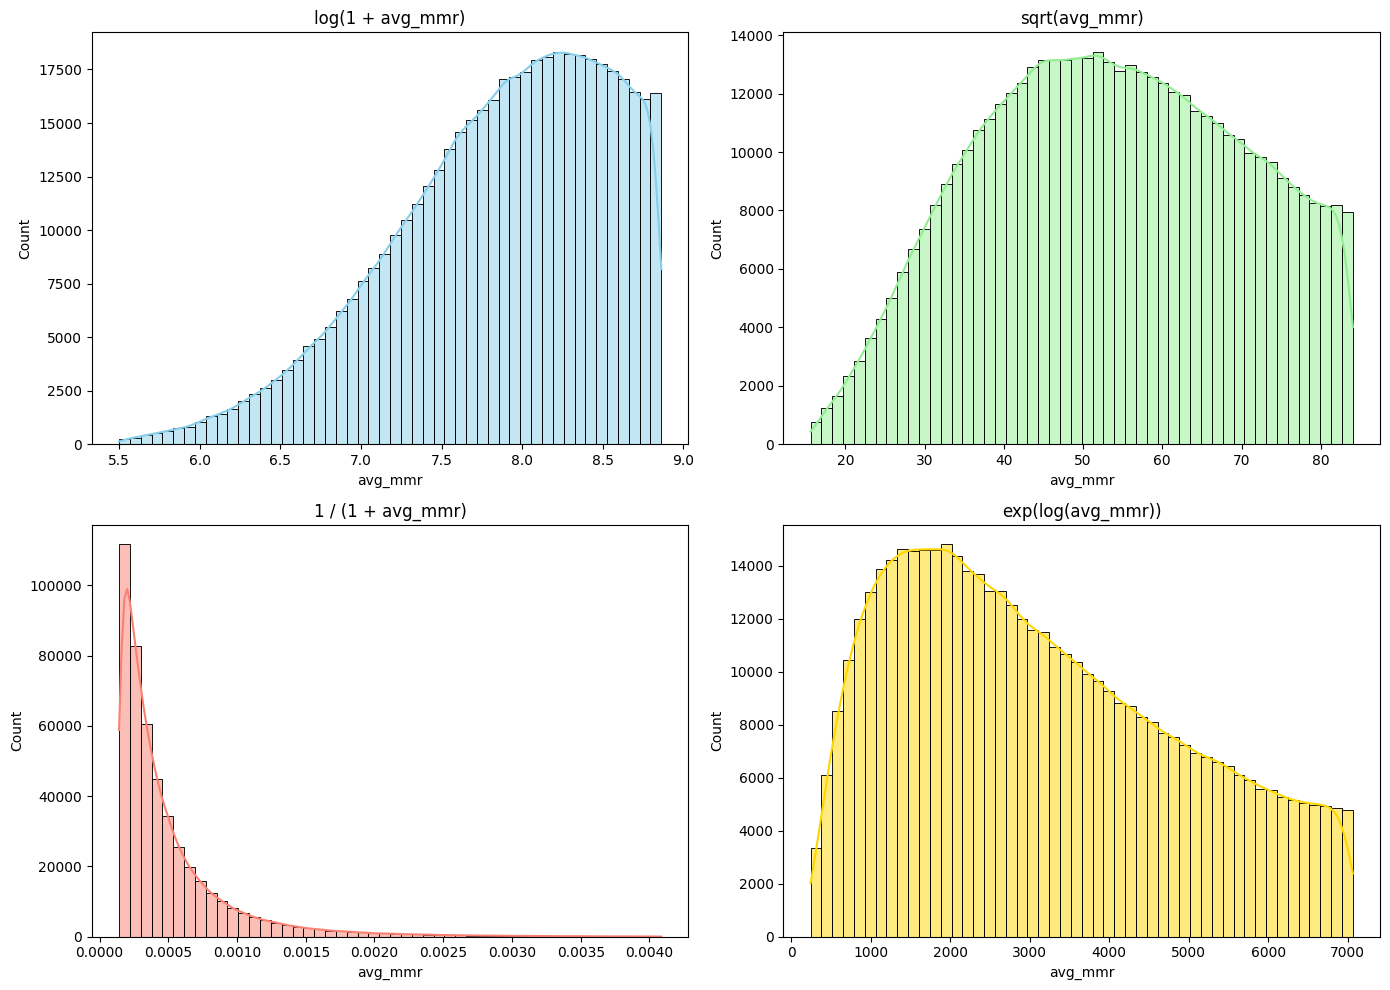

In [19]:
import numpy as np

mmr = train_df['avg_mmr']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(np.log1p(mmr), kde=True, ax=axes[0, 0], color='skyblue', bins=50)
axes[0, 0].set_title('log(1 + avg_mmr)')

sns.histplot(np.sqrt(mmr), kde=True, ax=axes[0, 1], color='lightgreen', bins=50)
axes[0, 1].set_title('sqrt(avg_mmr)')

sns.histplot(1 / (1 + mmr), kde=True, ax=axes[1, 0], color='salmon', bins=50)
axes[1, 0].set_title('1 / (1 + avg_mmr)')

sns.histplot(np.exp(np.log(mmr)), kde=True, ax=axes[1, 1], color='gold', bins=50)
axes[1, 1].set_title('exp(log(avg_mmr))')

plt.tight_layout()
plt.show()


Мы как-то раньше не обращали внимание, но шестое чувство подсказывает, что в ммрах есть пропуски. Выкинуть их не получится, потому что на тесте они тоже есть, поэтому выход один — чем-то заполнять.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

А пропуски у нас есть, потому что не все игры рейтинговые, там информацию по ммру собрать не удастся

В категориальных признаках пропуски не так важны для линрега, их можно закодировать специальной категорией. В числовых проигнорировать их не получится

В любом случае, лучше дополнительно добавить признак-флаг `mmr_missing`, который говорит, что пропуск там на самом деле есть. <font color="#cb9255">**Можете**</font> замерить его влияние, если есть желание, вдруг мы советуем полную дичь и там Джини 0.9?

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** нормально ли в данном случае заполнить пропуски нулём? А чем тогда, если нет?

**Ответ:** Заполнять пропуски рейтинга (avg_mmr) нулём - категорически нельзя.

</div>

Момент истины. Обучите две новые модели: к оптимальному набору фичей из предыдущего пункта добавьте в одном случае фичу без преобразования, а в другом — после преобразования. Зацените эффект на трейне и на валидации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Помните, что как бы ни было прекрасно и информативно преобразование в вашей голове, ключевое это перформанс на отложенной выборке \
В жизни каждого дата-сайентиста бывает такое, что фича, которая ну должна быть клёвой, <i>математически</i>, на практике оказывается той ещё жижей, и такое, увы, тоже нужно отслеживать

</div>

In [20]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

train_df['mmr_missing'] = train_df['avg_mmr'].isna().astype(int)
test_df['mmr_missing'] = test_df['avg_mmr'].isna().astype(int)

mmr_median = train_df['avg_mmr'].median()

train_df['avg_mmr_filled'] = train_df['avg_mmr'].fillna(mmr_median)
test_df['avg_mmr_filled'] = test_df['avg_mmr'].fillna(mmr_median)

train_df['avg_mmr_log'] = np.log1p(train_df['avg_mmr_filled'])
test_df['avg_mmr_log'] = np.log1p(test_df['avg_mmr_filled'])

train_df = train_df.sort_values('date').reset_index(drop=True)

split_index = int(len(train_df) * 0.8)
df_train = train_df.iloc[:split_index]
df_val = train_df.iloc[split_index:]

base_features = ['region_te', 'mmr_missing', 'is_weekend']

features_raw = base_features + ['avg_mmr_filled']
features_log = base_features + ['avg_mmr_log']

target = 'radiant_win'

clf_raw = LogisticRegression(max_iter=1000, random_state=42)
clf_log = LogisticRegression(max_iter=1000, random_state=42)

clf_raw.fit(df_train[features_raw], df_train[target])
clf_log.fit(df_train[features_log], df_train[target])

def calculate_gini(model, X, y):
    preds = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, preds)
    return 2 * auc - 1

print("=== Результаты моделирования (Метрика Gini) ===\n")

gini_train_raw = calculate_gini(clf_raw, df_train[features_raw], df_train[target])
gini_val_raw = calculate_gini(clf_raw, df_val[features_raw], df_val[target])
print(f"[Модель 1: База + Сырой MMR]")
print(f"Gini на Train:      {gini_train_raw:.5f}")
print(f"Gini на Validation: {gini_val_raw:.5f}\n")

gini_train_log = calculate_gini(clf_log, df_train[features_log], df_train[target])
gini_val_log = calculate_gini(clf_log, df_val[features_log], df_val[target])
print(f"[Модель 2: База + Преобразованный MMR (log1p)]")
print(f"Gini на Train:      {gini_train_log:.5f}")
print(f"Gini на Validation: {gini_val_log:.5f}")

=== Результаты моделирования (Метрика Gini) ===

[Модель 1: База + Сырой MMR]
Gini на Train:      0.14613
Gini на Validation: 0.14752

[Модель 2: База + Преобразованный MMR (log1p)]
Gini на Train:      0.14730
Gini на Validation: 0.14896


### **Часть 2. Векторы** (1.5 балла) <img align="center" height=28 width=28 src="https://static.wikia.nocookie.net/dota2_gamepedia/images/1/17/Emoticon_sick.gif/revision/latest?cb=20180504011850">

В которой студент испытывает вьетнамские флешбеки от дз1, фиксит чужие баги и делает нереально мощную фичу, которую можно полировать до посинения

#### **Задание 2.1. Большая чистка** (0.75 балла)

Пока что мы никак не использовали информацию про героев, а ведь от них напрямую зависит исход матча, их больше 100 штук и все они разные: кто-то сильнее, кто-то слабее, а кто-то красивее :3. Только в данные кто-то нагадил, придётся убирать! Тут придётся ещё разочек освежить `pandas`/`polars`

Датасеты, которые нас интересуют теперь — `player_df.csv` и `Constants.Heroes.csv`. Там есть и данные на трейне, и на тесте, мы их обязательно приджойним, но потом.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Данные, как и стойло, необходимо чистить. Ранее нам везло и в целом каких-то извращений мы не наблюдали, да и тут сходу не увидим. Т.н. *"выбросы"* это, во-первых, тема отдельного холивара, а во-вторых история про доменное несоответствие, матстат такое не найдёт, но на то у нас есть мозг, верно?

Под доменом имеется в виду контекст, в котором создаются ваши данные, и процессы которого ваши данные описывают (в нашем случае — то, как устроена игра и баланс в ней). Тогда выброс — это то, что в контекст не вписывается, даже если ошибки там нет. Про это весь пункт

</div>

Первое, что нужно отсмотреть - главные ключи. Начнём с игроков. Повертите `account_id`, вас должны смутить как минимум два айдишника.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Не все игроки делают свой профиль публичным, их айди в таком случае будет анонимизирован

Небольшая часть данных собрана некорректно, айди таких игроков тоже помечен особенным значением

</div>

In [21]:
import pandas as pd

player_df = pd.read_csv('player_df.csv')

print("=== Топ-5 самых частых account_id ===")
print(player_df['account_id'].value_counts().head(5))

suspicious_ids = [0, -1]
suspicious_count = player_df[player_df['account_id'].isin(suspicious_ids)].shape[0]
total_count = player_df.shape[0]

print(f"\nДоля подозрительных ID: {suspicious_count / total_count * 100:.2f}%")

=== Топ-5 самых частых account_id ===
account_id
 4294967295    2795673
-1               27267
 37619671          801
 84244723          763
 87266522          761
Name: count, dtype: int64

Доля подозрительных ID: 0.36%


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** можем ли мы себе позволить выкинуть матчи с какими-либо подозрительными айди без большого ущерба данным?

**Ответ:** Нет, категорически не можем. > В Dota 2 огромное количество игроков (часто более 50-60%) скрывают свою статистику настройками приватности.

</div>

Следующий логический шаг — одинаковых героев быть в одном матче не должно.  

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

В кастомных, т.е. не основных режимах игры, это может быть не так, но нас они не интересуют

</div>

Найдите, есть ли игры, в которых это по какой-то причине не так. Если таких матчей не слишком много, избавьтесь от них

In [22]:
dupes = player_df[player_df.duplicated(subset=['match_id', 'hero_id'], keep=False)]

bad_matches = dupes['match_id'].unique()

print(f"Количество 'сломанных' матчей с дубликатами героев: {len(bad_matches)}")

player_df_cleaned = player_df[~player_df['match_id'].isin(bad_matches)].copy()

if 'train_df' in globals():
    train_df = train_df[~train_df['match_id'].isin(bad_matches)].reset_index(drop=True)
    print("Сломанные матчи удалены из train_df.")

print(f"Размер player_df ДО очистки: {player_df.shape[0]}")
print(f"Размер player_df ПОСЛЕ очистки: {player_df_cleaned.shape[0]}")

player_df = player_df_cleaned

Количество 'сломанных' матчей с дубликатами героев: 1053
Сломанные матчи удалены из train_df.
Размер player_df ДО очистки: 7650825
Размер player_df ПОСЛЕ очистки: 7644422


Вы могли заметить героя-импостера под индексом 0. Если вы посмотрите в `Constants.Heroes.csv`, то его там не найдёте, потому что это тоже ошибка.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Скорее всего это те, кто не успел выбрать героя, игра могла просто не начаться

Вряд ли у нас получится заполнить пропуски чем-то адекватным — они зависят от игрока и героя, переменных много. Попробовать можно, но точно не в базовой части

</div>

Финальным аккордом:

- посмотрите, что за игроки играли на герое с `hero_id=0`, и выкиньте такие матчи вместе со всеми пропусками
- найдите игроков, которые в одном матче играли одновременно и за команду сил Тьмы (слоты `{128, ..., 132}`), и за команду сил Света (слоты `{0, ..., 4}`), не являясь подозрительными айди из пункта выше, уберите их
- отфильтруйте `player_df`, оставьте только те матчи, которые есть в наших выборках
- проверьте, что в каждом матче ровно 5 игроков за Свет и ровно 5 за Тьму

Можно в любом порядке, но эти вещи нужно проверить, они поломают следующий пункт

In [23]:
bad_hero_matches = player_df[player_df['hero_id'] == 0]['match_id'].unique()
player_df = player_df[~player_df['match_id'].isin(bad_hero_matches)]

suspicious_ids = [0, -1]
players_both_teams = player_df[~player_df['account_id'].isin(suspicious_ids)]
players_both_teams = players_both_teams.groupby(['match_id', 'account_id'])['player_slot'].apply(
    lambda x: (x < 5).any() and (x >= 128).any()
)
bad_player_matches = players_both_teams[players_both_teams].index.get_level_values('match_id').unique()
player_df = player_df[~player_df['match_id'].isin(bad_player_matches)]

all_match_ids = set(train_df['match_id']) | set(test_df['match_id'])
player_df = player_df[player_df['match_id'].isin(all_match_ids)]

def check_5v5(df):
    counts = df.groupby('match_id')['player_slot'].apply(
        lambda x: ((x < 5).sum() == 5) and ((x >= 128).sum() == 5)
    )
    return counts[counts].index.unique()

valid_5v5_matches = check_5v5(player_df)
player_df = player_df[player_df['match_id'].isin(valid_5v5_matches)]

train_df = train_df[train_df['match_id'].isin(player_df['match_id'])].reset_index(drop=True)
test_df = test_df[test_df['match_id'].isin(player_df['match_id'])].reset_index(drop=True)

print(f"Чистка окончена. Осталось матчей в Train: {len(train_df)}")

Чистка окончена. Осталось матчей в Train: 238040


Если вас всё же одолевает паранойя, то ~~я вас понимаю~~ будьте уверены, что если проблемы в `player_df` и остались, на модель они повлияют минимально. Ну а идеала не бывает нигде

#### **Задание 2.2. Энкодер героев** (0.75 балла)

А зачем мы вообще этим занимаемся? Вопрос хороший. План был в том, чтобы закодировать комбинации героев, которые участвуют в матче. Это чуть более сложный признак, чем обычный трансформ, тут придется поколдовать.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея в том, что какие-то комбинации героев эффективнее других. Если понять, что в матче за персонажи, можно сразу же прикинуть шансы на победу одной из сторон

</div>

Ваша задача - закодировать каждый матч вектором вида:

| match_id | hero_1 | hero_2 | hero_3 | ... | hero_n |
| --- | --- | --- | --- | --- | --- |
| 228 | 1 | 0 | -1 | ... | 0 |

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Потом <font color="#cb9255">**можно**</font> бахнуть One-Hot и разбить героев на две команды, если не боитесь переобучения. Вещь необязательная

</div>

Потребуются таблицы `player_df.csv` и `matches_df_*.csv`. Для удобства может пригодиться `Constants.Heroes.csv` (индексы оттуда и в `player_df` верные, по ним можно джойнить, но они идут не по порядку, не смотрите на пандасовский айди).

Хочется видеть либо функцию, либо в идеале класс, который вертит фичами вот так:

Каждый элемент в векторе матча `(hero_1, ..., hero_n)` принимает значение 1, если герой был в команде сил Света (слоты `{0, ..., 4}`), и -1, если в команде сил Тьмы (слоты `{128, ..., 132}`).

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Класс нужен, поскольку при неаккуратной реализации есть риск не влезть в память при трансформе целого датасета. Главное, чтобы была функция, а там можно применять её на батч.

Либо же <font color="#cb9255">**можете**</font> преисполниться спарс матрицами, которые экономно (не) хранят миллионы нулей. Вещь несложная и полезная

</div>

Реализуйте то, что написано

In [24]:
from scipy.sparse import csr_matrix
import numpy as np

class HeroesEncoder:
    def __init__(self):
        self.max_hero_id = 0

    def fit(self, X, y=None):
        self.max_hero_id = X['hero_id'].max()
        return self

    def transform(self, X):

        match_ids = X['match_id'].unique()
        match_map = {mid: i for i, mid in enumerate(match_ids)}

        rows = X['match_id'].map(match_map).values
        cols = X['hero_id'].values

        data = X['player_slot'].apply(lambda s: 1 if s < 5 else -1).values

        sparse_heroes = csr_matrix((data, (rows, cols)),
                                   shape=(len(match_ids), self.max_hero_id + 1))

        return sparse_heroes, match_ids

he = HeroesEncoder()
he.fit(player_df)


train_player_data = player_df[player_df['match_id'].isin(train_df['match_id'])]
test_player_data = player_df[player_df['match_id'].isin(test_df['match_id'])]

X_heroes_train, train_mids = he.transform(train_player_data)
X_heroes_test, test_mids = he.transform(test_player_data)

print(f"Форма матрицы героев (Train): {X_heroes_train.shape}")

Форма матрицы героев (Train): (238040, 113)


Осталось лишь самое сладкое — проверить фичу в деле. Обучите две модели: одну со всеми фичами, что мы накрутили, и одну только с фичами героев, покажите качество

In [25]:
from sklearn.linear_model import Ridge

from sklearn.linear_model import LogisticRegression
lr_heroes = LogisticRegression(C=0.1, solver='liblinear')
lr_heroes.fit(X_heroes_train, train_df['radiant_win'])

gini_heroes = calculate_gini(lr_heroes, X_heroes_train, train_df['radiant_win'])
print(f"Gini (Только герои): {gini_heroes:.5f}")


from scipy.sparse import hstack


numeric_features = ['region_te', 'avg_mmr_log', 'is_weekend', 'mmr_missing']
X_num_train = train_df[numeric_features].values


X_full_train = hstack([csr_matrix(X_num_train), X_heroes_train])

lr_full = LogisticRegression(C=0.1, solver='liblinear')
lr_full.fit(X_full_train, train_df['radiant_win'])

gini_full = calculate_gini(lr_full, X_full_train, train_df['radiant_win'])
print(f"Gini (Все фичи + Герои): {gini_full:.5f}")

Gini (Только герои): 0.02467
Gini (Все фичи + Герои): 0.15102


Итого у вас должно получиться что-то на уровне $\text{Gini} = 0.25$ на тесте, а может даже выше

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Вы могли заметить, что прирост получится не таким значительным, как можно было ожидать, хотя признак сильный. Чем больше добавлять хороших признаков, тем лучше и лучше они объясняют данные.

Даже сложный и хороший по отдельности признак в комбинации с другими будет давать всё меньшее качество. Отчасти это объясняется мультиколлинеарностью, отчасти природой данных, некоторые из них просто слишком сложны

</div>

### **Часть 3. Оптимизация для уже смешариков (1.25 балла)** <img height=28 width=28 align="center" src="https://cdn.7tv.app/emote/01H8RPMSBR000133946WK71YXM/1x.avif">

В которой студент изучает, как оптимизировать модель **по-взрослому**

#### **Задание 3.1. Optuna для самых маленьких** (0.75 балла)

Не стоит забывать, что у любой модели есть <font color="#cb9255">**гиперпараметры**</font>. Конечно, львиная доля качества будет идти от фичей, но списывать параметры со счетов не стоит. В конце концов, бывает, что с безнадёжным на первый взгляд набором признаков, оптимизированная модель покажет лучшее качество, чем базовая модель на топовых фичах, вот и посмотрим.
<a id="section"></a>

Для эффективного подбора гиперпараметров существует несколько решений, основанных на байесовской оптимизации. Одно из наиболее удобных — [optuna](https://optuna.org/), которая делает перебор гиперпараметров таким же лёгким и увлекательным занятием, как составление домашек по МО.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея — смоделировать, какой набор гиперпараметров даст лучшее качество там, где перспективнее, на основе истории их подбора (подробнее на МО2)

</div>

Напишите функцию оптимизации для вашего классификатора. Можете воспользоваться шаблоном ниже, но он довольно куцый, курите документацию. Раз уж инструмент новый, начнём с чего-то простого. Подберите вот такие гиперпараметры (посмотрите на них, прежде, чем тюнить, у них разные диапазоны и разный же смысл (логарифмическая шкала — наш лучший друг, возможно даже лучше настоящих)):

1) Численный — `alpha` у `SGDClassifier` или параметр регуляризации `C` у всех остальных.
2) Категориальный — `solver` у `LogisticRegression`, `loss` у всех остальных
3) Число итераций — `max_iter`. Это не совсем гиперпараметр, но поверьте, обучать модель 100 лет вы не хотите, к тому же это вид неявной регуляризации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Раз уж все алгоритмы у нас итерационные, от того, как и по какой функции оптимизироваться, довольно важно

Способов применять оптуну вновь два. Выбор, как всегда, в ваших руках:\
<font color="#cb9255">**Первое**</font> — тестить после каждой фичи, это точнее, но можем переобучиться. <font color="#cb9255"> \
**Второе**</font> — подобрать параметры один раз, это проще, но зато быстро. У нас модель простая и перебирать там можно мало чего, пока что, во второй части параметров станет больше. \

</div>

In [29]:
!pip install -qU optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.1 MB/s eta 0:00:00


In [30]:
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
import numpy as np # Import numpy

def objective(trial):
    params = {
        'C': trial.suggest_float('C', 1e-5, 10, log=True),
        'solver': trial.suggest_categorical('solver', ['liblinear', 'lbfgs']),
        'max_iter': trial.suggest_int('max_iter', 100, 1000),
        'random_state': 42
    }

    model = LogisticRegression(**params)


    tscv = TimeSeriesSplit(n_splits=3)
    gini_scores = []


    for train_idx, val_idx in tscv.split(X_full_train):

        X_t, X_v = X_full_train.tocsr()[train_idx], X_full_train.tocsr()[val_idx]
        y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_t, y_t)
        preds = model.predict_proba(X_v)[:, 1]

        auc = roc_auc_score(y_v, preds)
        gini_scores.append(2 * auc - 1)


    return np.mean(gini_scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25, show_progress_bar=True)

print("\nЛучшие параметры:", study.best_params)
print("Лучший Gini:", study.best_value)

[I 2026-04-20 07:01:42,897] A new study created in memory with name: no-name-0ea4b11c-02da-416f-891b-eaf7069fda8b


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-04-20 07:01:49,113] Trial 0 finished with value: -0.0043619867342888545 and parameters: {'C': 0.01196893478539881, 'solver': 'liblinear', 'max_iter': 860}. Best is trial 0 with value: -0.0043619867342888545.
[I 2026-04-20 07:01:53,483] Trial 1 finished with value: -0.00418545122244988 and parameters: {'C': 0.1850875979499395, 'solver': 'liblinear', 'max_iter': 223}. Best is trial 1 with value: -0.00418545122244988.
[I 2026-04-20 07:01:58,577] Trial 2 finished with value: -0.004132539528660661 and parameters: {'C': 1.3407300409185434, 'solver': 'liblinear', 'max_iter': 222}. Best is trial 2 with value: -0.004132539528660661.
[I 2026-04-20 07:02:01,263] Trial 3 finished with value: -0.0037768199591174945 and parameters: {'C': 1.2941174753571015e-05, 'solver': 'lbfgs', 'max_iter': 980}. Best is trial 3 with value: -0.0037768199591174945.
[I 2026-04-20 07:02:02,481] Trial 4 finished with value: -0.0035428060255081606 and parameters: {'C': 2.310452686586098e-05, 'solver': 'liblinear

#### **Задание 3.2. Немножко про интерпретацию** (0.25 балла)

В оптуне лежит целая россыпь визуализаций, как же их не пощупать? Чтобы окончательно убедить вас в ценности и важности регуляризации, выведите график важности гиперпараметров. Оценим, что реально важно, а что пшик

In [31]:
import optuna.visualization as vis


vis.plot_optimization_history(study).show()


vis.plot_param_importances(study).show()


vis.plot_parallel_coordinate(study).show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы видите и как вы прокомментируете, какие параметры важнее всего?

**Ответ:** В линейных моделях (Logistic Regression) именно C определяет баланс между недообучением и переобучением. Поскольку у нас очень много признаков после добавления героев (разреженная матрица), модель крайне чувствительна к тому, насколько сильно мы «штрафуем» большие веса.

</div>

#### **Задание 3.3. Заключение** (0.25 балла)

Фуух, много конечно, ну да так уж вышло, что теперь делать, данные это всегда геморрой. Напоследок:

1. Зафиксируйте оптимальный набор гиперпараметров.
2. Сохраните либо модель, либо pipeline для будущего себя в части advanced.
3. Сделайте тестовый submission на [Kaggle](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105), если ещё не.

In [32]:
import pandas as pd
from scipy.sparse import hstack

best_params = study.best_params
print(f"Финальные параметры: {best_params}")

final_model = LogisticRegression(**best_params)
final_model.fit(X_full_train, train_df['radiant_win'])

X_num_test = test_df[['region_te', 'avg_mmr_log', 'is_weekend', 'mmr_missing']].values

X_full_test = hstack([csr_matrix(X_num_test), X_heroes_test])



test_preds = final_model.predict_proba(X_full_test)[:, 1]


submission = pd.DataFrame({
    'match_id': test_df['match_id'],
    'radiant_win': test_preds
})

submission.to_csv('submission_final.csv', index=False)
print("Файл submission_final.csv готов! Пора на Kaggle!")


import joblib
joblib.dump(final_model, 'dota_model_v1.pkl')

Финальные параметры: {'C': 1.3075649673120305e-05, 'solver': 'liblinear', 'max_iter': 338}
Файл submission_final.csv готов! Пора на Kaggle!


['dota_model_v1.pkl']